# Context

**Dataset:** Hillstrom / MineThatData email challenge (64,000 customers), loaded via `sklift.datasets.fetch_hillstrom`.

**Design:** A randomized experiment with three arms — 1/3 Mens E-Mail, 1/3 Womens E-Mail, 1/3 No E-Mail (control). The outcome used here is `visit`: 1 if the customer visited the website in the two weeks following the campaign.

**Project framing:** The goal of this project is to learn from a past campaign — the Hillstrom experiment — in order to inform who should receive the next one. The question is not whether the campaign worked overall, which a difference in means can answer. It's which customers the email actually moves, so that future sends can be targeted rather than blanket.
That breaks into three stages:

1. **Validate the data** — quality checks, and confirm the randomization actually balanced the arms, since everything downstream depends on it.
2. **Model the heterogeneity** — train an uplift model to estimate customer-level treatment effects and surface the pattern of who responds.
3. **Translate to a recommendation** — who to target next time, and what that decision is worth.


In [16]:
import pandas as pd
import numpy as np
from sklift.datasets import fetch_hillstrom

pd.set_option('display.max_columns', None)

## EDA

In [17]:
bunch = fetch_hillstrom(target_col='visit')

df = bunch.data.copy()
df['segment'] = bunch.treatment
df['visit'] = bunch.target

print(df.shape)
df.head()

(64000, 10)


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0


In [18]:
df.dtypes

recency              int64
history_segment     object
history            float64
mens                 int64
womens               int64
zip_code            object
newbie               int64
channel             object
segment             object
visit                int64
dtype: object

In [19]:
df.isna().sum()

recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
segment            0
visit              0
dtype: int64

In [20]:
df['channel'].value_counts()

channel
Web             28217
Phone           28021
Multichannel     7762
Name: count, dtype: int64

In [21]:
df = df.reset_index().rename(columns={'index': 'customer_id'})

In [22]:
df.head()

,customer_id,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit
0,0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0
1,1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0
2,2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0
3,3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0
4,4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0


### Arm sizes

In [23]:
df['segment'].value_counts()

segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64

### Collapse to two-arm treatment indicator

the main analysis collapses Mens E-Mail + Womens E-Mail into a single `treatment = 1` ("any email") vs. `treatment = 0` ("No E-Mail").

In [24]:
df['treatment'] = (df['segment'] != 'No E-Mail').astype(int)
df['treatment'].value_counts()

treatment
1    42694
0    21306
Name: count, dtype: int64

### Randomization balance check

This is the core sanity check for this notebook: if randomization worked, the two arms (`treatment` 0 vs. 1) should look statistically indistinguishable on every *pre-treatment* covariate — recency, history, mens/womens purchase history, channel, zip/urban-rural, and newbie status. Any imbalance here is a real RCT-integrity flag (not necessarily fatal, but it must be surfaced), not something to explain away silently.

**Handed off to you from here on** — EDA, the balance tests themselves (what test fits a continuous covariate vs. a categorical one, and why), interpretation, and everything downstream (baseline model, uplift model, evaluation, profit curve, write-up).

In [26]:
df.head()

,customer_id,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,treatment
0,0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,1
1,1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0
2,2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,1
3,3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,1
4,4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,1


In [32]:
# randomization check
from scipy import stats

continuous_vars = ['recency', 'history']
binary_vars = ['mens', 'womens', 'newbie']
categorical_vars = ['channel', 'zip_code', 'history_segment']

res= []

for col in continuous_vars:
    treated = df.loc[df['treatment'] == 1, col]
    control = df.loc[df['treatment'] == 0, col]
    t_stat, pval = stats.ttest_ind(treated, control, equal_var=False)
    res.append(
        {
            'covariate': col,
            'test': 'Welch t-test', 
            'Statistic': t_stat,
            'p value': pval
        }
    )

for col in binary_vars + categorical_vars:
    contingency = pd.crosstab(df[col], df['treatment'])
    stat, p, dof, expected = stats.chi2_contingency(contingency)
    res.append(
            {
                'covariate': col,
                'test': 'chi-square', 
                'Statistic': stat,
                'p value': p
            }
    )

table = pd.DataFrame(res).round(3)

# testing 8 covariates at once inflats the false-positive rate; Bonferroni-adjust the threshold
alpha = 0.05 / len(table)
table['imbalanced'] = table['p value'] < alpha
table


,covariate,test,Statistic,p value,imbalanced
0,recency,Welch t-test,0.716,0.474,False
1,history,Welch t-test,0.845,0.398,False
2,mens,chi-square,0.608,0.436,False
3,womens,chi-square,0.545,0.460,False
4,newbie,chi-square,0.008,0.927,False
5,channel,chi-square,0.348,0.840,False
6,zip_code,chi-square,1.257,0.533,False
7,history_segment,chi-square,5.310,0.505,False


### Outcome distribution check

In [ ]:
bunch_all = fetch_hillstrom(target_col='all')
df['conversion'] = bunch_all.target['conversion']

In [35]:
# 1. overall and control baseline rates, visits vs conversion side by side
baseline = pd.DataFrame({
    'overall_rate': df[['visit', 'conversion']].mean(),
    'control_rate': df.loc[df['treatment'] == 0, ['visit', 'conversion']].mean()
})

baseline

,overall_rate,control_rate
visit,0.146781,0.106167
conversion,0.009031,0.005726


In [37]:
# 2. rate by original 3-arm segment (before collapsing to treatment/control)
segment_rates = df.groupby('segment')['visit'].mean().sort_values(ascending=False)
segment_rates

segment
Mens E-Mail      0.182757
Womens E-Mail    0.151400
No E-Mail        0.106167
Name: visit, dtype: float64

In [39]:
# 3. dirty value check, visit/conversion should only ever be {0,1}
print("clean:", df['visit'].isin([0,1]).all() and df['conversion'].isin([0,1]).all())

clean: True


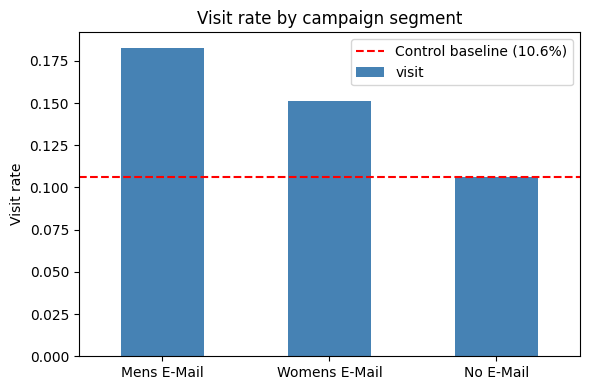

In [40]:
import matplotlib.pyplot as plt

control_rate = df.loc[df['treatment'] == 0, 'visit'].mean()

fig, ax = plt.subplots(figsize=(6,4))
segment_rates.plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(control_rate, color='red', linestyle='--', label=f'Control baseline ({control_rate:.1%})')
ax.set_ylabel('Visit rate')
ax.set_xlabel('')
ax.set_title('Visit rate by campaign segment')
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()